# Step 1: Baseline AI Classifier Comparison

## 🎯 Objective:
Membandingkan **2 model sederhana** untuk regime classification:
1. **Random Forest** (ensemble, non-linear)
2. **Logistic Regression** (linear, interpretable)

## 📊 Features (Baseline - 3 features):
- `Vol_20`: 20-day rolling volatility (market-wide)
- `Mom_20`: 20-day rolling momentum (market-wide)
- `Mom_50`: 50-day rolling momentum (market-wide)

## 🎓 Classification Task:
- **Binary Classification**: Bearish (0) vs Bullish (1)
- **Target**: Next-day market regime (based on market return > 0)
- **Train**: 2023-2024
- **Test**: 2025

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Models to compare:")
print("  1. Random Forest Classifier")
print("  2. Logistic Regression")

✅ Libraries loaded successfully!

📦 Models to compare:
  1. Random Forest Classifier
  2. Logistic Regression


## 1. Data Loading

In [2]:
# Load data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets ({len(data.columns)}): {list(data.columns)}")
print(f"\n📈 Sample data:")
print(data.head())

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets (24): ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']

📈 Sample data:
             AAVE-USD   ADA-USD     BCH-USD     BNB-USD       BTC-USD  \
Date                                                                    
2023-04-17  81.023987  0.434167  131.615753  339.994110  29445.044922   
2023-04-18  81.884674  0.443752  133.601685  343.193451  30397.552734   
2023-04-19  74.032852  0.415793  125.092918  322.707520  28822.679688   
2023-04-20  72.408966  0.400731  123.110573  317.889923  28245.988281   
2023-04-21  69.108185  0.382939  119.750771  321.674988  27276.910156   

             CRO-USD   DAI-USD   DASH-USD  DOGE-USD      ETH-USD  ...  \
Date                                

## 2. Feature Engineering (Baseline - 3 Features)

In [3]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)  # Market-wide average return

print("📊 Market Return Statistics:")
print(market_return.describe())

# Create baseline features
features = pd.DataFrame(index=returns.index)

# Feature 1: 20-day volatility
features['Vol_20'] = market_return.rolling(window=20).std()

# Feature 2: 20-day momentum
features['Mom_20'] = market_return.rolling(window=20).mean()

# Feature 3: 50-day momentum
features['Mom_50'] = market_return.rolling(window=50).mean()

# Target: Binary classification (0=Bearish, 1=Bullish)
features['Target'] = (market_return.shift(-1) > 0).astype(int)

# Drop NaN values
features = features.dropna()

print("\n✅ Features created:")
print(f"  Total features: {len(features.columns) - 1}")
print(f"  Feature names: {list(features.columns[:-1])}")
print(f"  Total samples: {len(features)}")

print("\n📊 Feature Statistics:")
print(features.describe())

print("\n📊 Target Distribution:")
target_dist = features['Target'].value_counts()
print(f"  Bearish (0): {target_dist[0]} days ({target_dist[0]/len(features)*100:.1f}%)")
print(f"  Bullish (1): {target_dist[1]} days ({target_dist[1]/len(features)*100:.1f}%)")

📊 Market Return Statistics:
count    977.000000
mean            inf
std             NaN
min       -0.125184
25%       -0.012842
50%        0.002450
75%        0.016931
max             inf
dtype: float64

✅ Features created:
  Total features: 3
  Feature names: ['Vol_20', 'Mom_20', 'Mom_50']
  Total samples: 927

📊 Feature Statistics:
           Vol_20      Mom_20      Mom_50      Target
count  927.000000  927.000000  927.000000  927.000000
mean     0.026746    0.001915    0.001912    0.548004
std      0.008193    0.006304    0.004056    0.497959
min      0.010481   -0.014521   -0.006813    0.000000
25%      0.020885   -0.002194   -0.001175    0.000000
50%      0.026325    0.001098    0.001255    1.000000
75%      0.031759    0.005080    0.004360    1.000000
max      0.049392    0.025813    0.013732    1.000000

📊 Target Distribution:
  Bearish (0): 419 days (45.2%)
  Bullish (1): 508 days (54.8%)


## 3. Train/Test Split

In [4]:
# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, ['Vol_20', 'Mom_20', 'Mom_50']]
y_test = features.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set:")
print(f"  Samples: {len(X_train)}")
print(f"  Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"  Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set:")
print(f"  Samples: {len(X_test)}")
print(f"  Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"  Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set:
  Samples: 562
  Period: 2023-06-19 to 2024-12-31
  Bearish: 250 | Bullish: 312

🧪 Testing Set:
  Samples: 365
  Period: 2025-01-01 to 2025-12-31
  Bearish: 169 | Bullish: 196


## 4. Model Training

### 4.1 Random Forest Classifier

In [5]:
print("🌲 Training Random Forest Classifier...\n")

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predictions
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained successfully!")
print(f"   Trees: {rf_model.n_estimators}")
print(f"   Features used: {rf_model.n_features_in_}")

🌲 Training Random Forest Classifier...

✅ Random Forest trained successfully!
   Trees: 100
   Features used: 3


### 4.2 Logistic Regression

In [6]:
print("📈 Training Logistic Regression...\n")

# Initialize Logistic Regression
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)

# Train
lr_model.fit(X_train, y_train)

# Predictions
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)
lr_test_proba = lr_model.predict_proba(X_test)[:, 1]

print("✅ Logistic Regression trained successfully!")
print(f"   Coefficients: {lr_model.coef_[0]}")
print(f"   Intercept: {lr_model.intercept_[0]:.4f}")

# Show feature importance (coefficients)
print("\n📊 Feature Coefficients (Logistic Regression):")
for feature, coef in zip(X_train.columns, lr_model.coef_[0]):
    print(f"   {feature}: {coef:+.4f}")

📈 Training Logistic Regression...

✅ Logistic Regression trained successfully!
   Coefficients: [-0.03845811  0.07023231 -0.02713947]
   Intercept: 0.2226

📊 Feature Coefficients (Logistic Regression):
   Vol_20: -0.0385
   Mom_20: +0.0702
   Mom_50: -0.0271


## 5. Performance Comparison

In [7]:
def calculate_metrics(y_true, y_pred, model_name, dataset_name):
    """Calculate and display performance metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Calculate metrics for all combinations
results = []

# Random Forest
results.append(calculate_metrics(y_train, rf_train_pred, 'Random Forest', 'Training'))
results.append(calculate_metrics(y_test, rf_test_pred, 'Random Forest', 'Testing'))

# Logistic Regression
results.append(calculate_metrics(y_train, lr_train_pred, 'Logistic Regression', 'Training'))
results.append(calculate_metrics(y_test, lr_test_pred, 'Logistic Regression', 'Testing'))

# Create comparison dataframe
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("PERFORMANCE COMPARISON TABLE")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)


Random Forest - Training
Accuracy:  0.9359 (93.59%)
Precision: 0.9233
Recall:    0.9647
F1-Score:  0.9436

Random Forest - Testing
Accuracy:  0.5205 (52.05%)
Precision: 0.5393
Recall:    0.7347
F1-Score:  0.6220

Logistic Regression - Training
Accuracy:  0.5552 (55.52%)
Precision: 0.5552
Recall:    1.0000
F1-Score:  0.7140

Logistic Regression - Testing
Accuracy:  0.5370 (53.70%)
Precision: 0.5370
Recall:    1.0000
F1-Score:  0.6988

PERFORMANCE COMPARISON TABLE
              Model  Dataset  Accuracy  Precision   Recall  F1-Score
      Random Forest Training  0.935943   0.923313 0.964744  0.943574
      Random Forest  Testing  0.520548   0.539326 0.734694  0.622030
Logistic Regression Training  0.555160   0.555160 1.000000  0.713959
Logistic Regression  Testing  0.536986   0.536986 1.000000  0.698752


## 6. Confusion Matrix Comparison

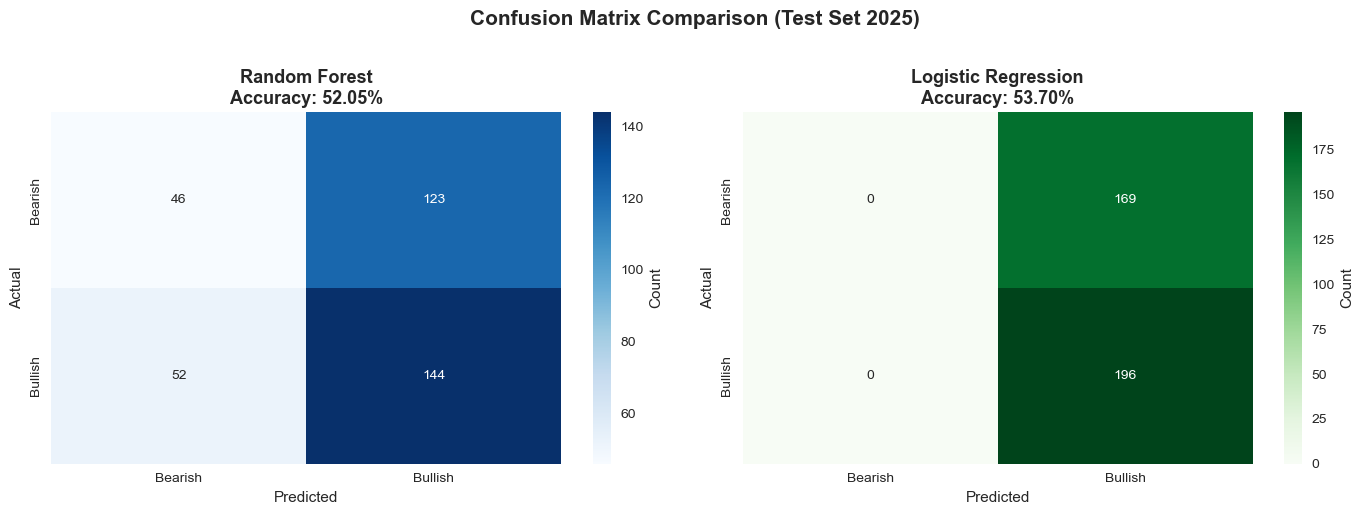

In [8]:
# Create confusion matrices
cm_rf = confusion_matrix(y_test, rf_test_pred)
cm_lr = confusion_matrix(y_test, lr_test_pred)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
rf_acc = accuracy_score(y_test, rf_test_pred)
axes[0].set_title(f'Random Forest\nAccuracy: {rf_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
lr_acc = accuracy_score(y_test, lr_test_pred)
axes[1].set_title(f'Logistic Regression\nAccuracy: {lr_acc:.2%}', 
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrix Comparison (Test Set 2025)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Actual vs Predicted Comparison

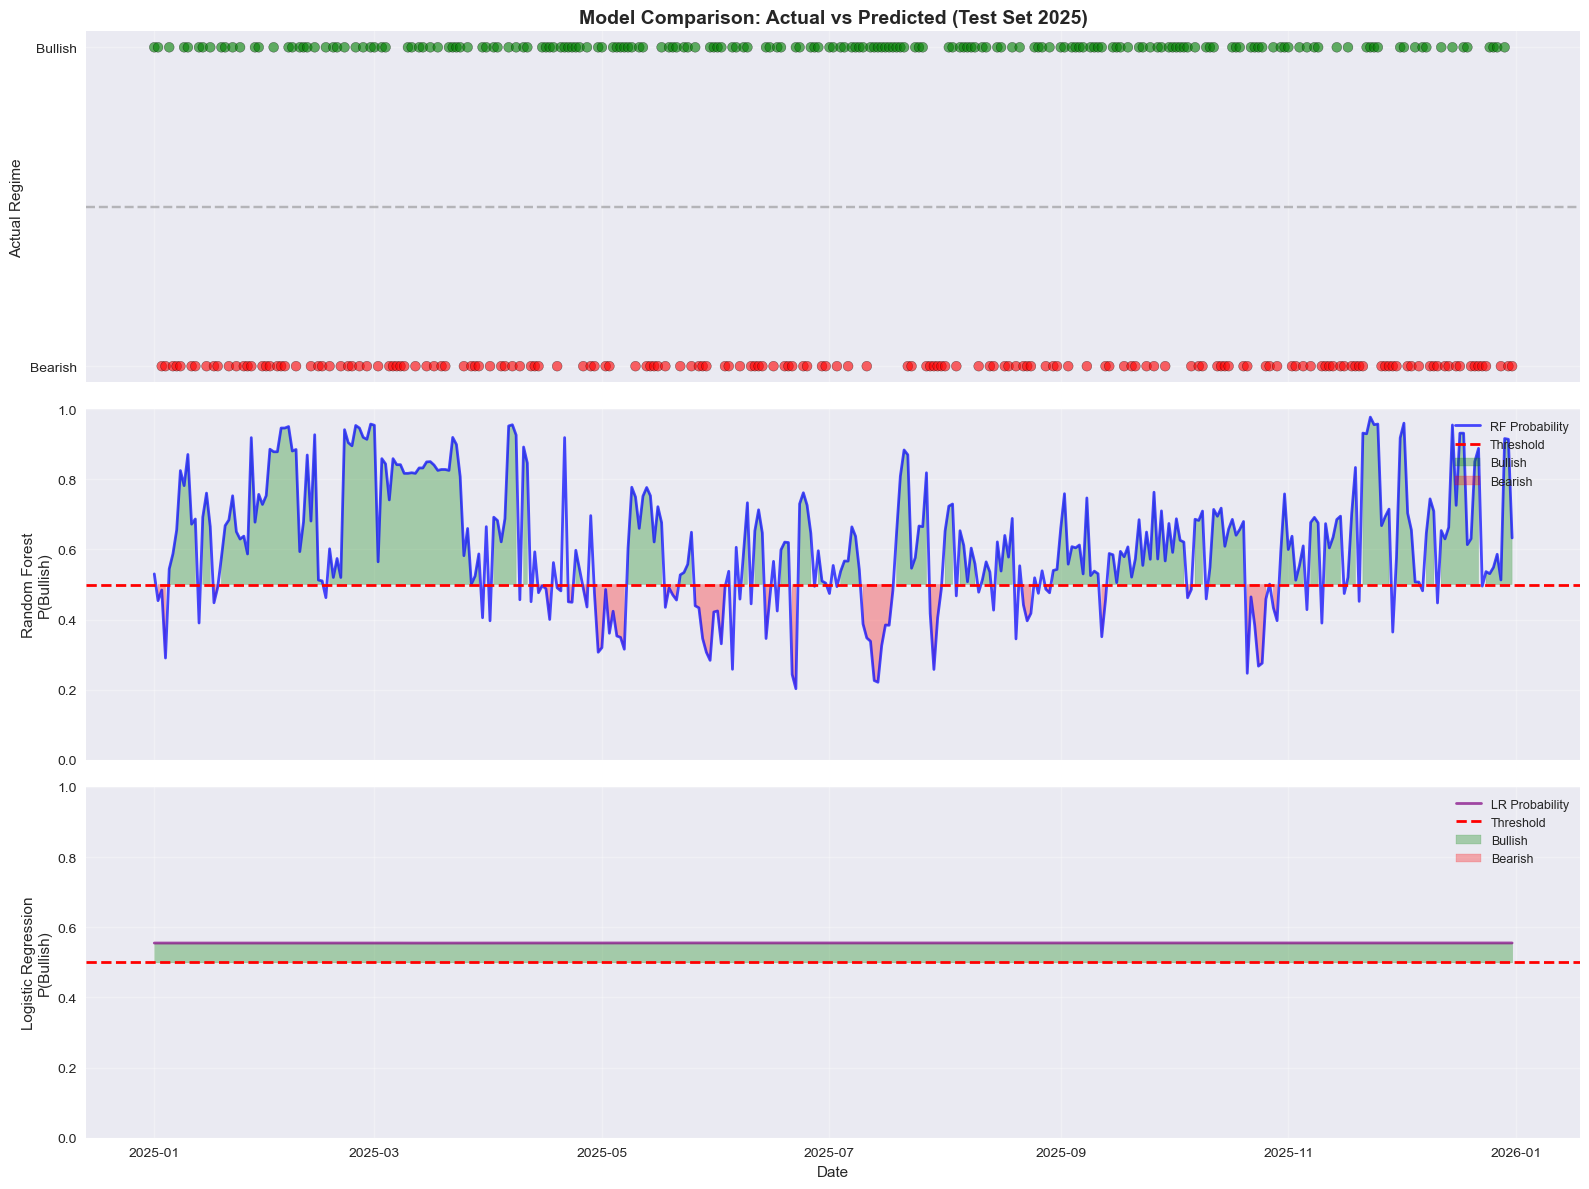


📊 Prediction Agreement:
  RF Correct: 190/365 (52.1%)
  LR Correct: 196/365 (53.7%)
  Both Correct: 144/365 (39.5%)


In [9]:
# Create comparison dataframe
comparison = pd.DataFrame({
    'Actual': y_test,
    'RF_Pred': rf_test_pred,
    'LR_Pred': lr_test_pred,
    'RF_Proba': rf_test_proba,
    'LR_Proba': lr_test_proba
}, index=y_test.index)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 1. Actual regime
colors_actual = ['red' if x == 0 else 'green' for x in comparison['Actual']]
axes[0].scatter(comparison.index, comparison['Actual'], 
                c=colors_actual, alpha=0.6, s=50, edgecolors='black')
axes[0].set_ylabel('Actual Regime', fontsize=11)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Bearish', 'Bullish'])
axes[0].set_title('Model Comparison: Actual vs Predicted (Test Set 2025)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

# 2. Random Forest predictions
axes[1].plot(comparison.index, comparison['RF_Proba'], 
             linewidth=2, color='blue', alpha=0.7, label='RF Probability')
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].fill_between(comparison.index, 0.5, comparison['RF_Proba'],
                     where=(comparison['RF_Proba'] >= 0.5), 
                     alpha=0.3, color='green', label='Bullish')
axes[1].fill_between(comparison.index, comparison['RF_Proba'], 0.5,
                     where=(comparison['RF_Proba'] < 0.5), 
                     alpha=0.3, color='red', label='Bearish')
axes[1].set_ylabel('Random Forest\nP(Bullish)', fontsize=11)
axes[1].set_ylim([0, 1])
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

# 3. Logistic Regression predictions
axes[2].plot(comparison.index, comparison['LR_Proba'], 
             linewidth=2, color='purple', alpha=0.7, label='LR Probability')
axes[2].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[2].fill_between(comparison.index, 0.5, comparison['LR_Proba'],
                     where=(comparison['LR_Proba'] >= 0.5), 
                     alpha=0.3, color='green', label='Bullish')
axes[2].fill_between(comparison.index, comparison['LR_Proba'], 0.5,
                     where=(comparison['LR_Proba'] < 0.5), 
                     alpha=0.3, color='red', label='Bearish')
axes[2].set_ylabel('Logistic Regression\nP(Bullish)', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].legend(loc='upper right', fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate agreement
rf_match = (comparison['Actual'] == comparison['RF_Pred']).sum()
lr_match = (comparison['Actual'] == comparison['LR_Pred']).sum()
both_correct = ((comparison['Actual'] == comparison['RF_Pred']) & 
                (comparison['Actual'] == comparison['LR_Pred'])).sum()

print(f"\n📊 Prediction Agreement:")
print(f"  RF Correct: {rf_match}/{len(comparison)} ({rf_match/len(comparison)*100:.1f}%)")
print(f"  LR Correct: {lr_match}/{len(comparison)} ({lr_match/len(comparison)*100:.1f}%)")
print(f"  Both Correct: {both_correct}/{len(comparison)} ({both_correct/len(comparison)*100:.1f}%)")

## 8. Feature Importance Analysis

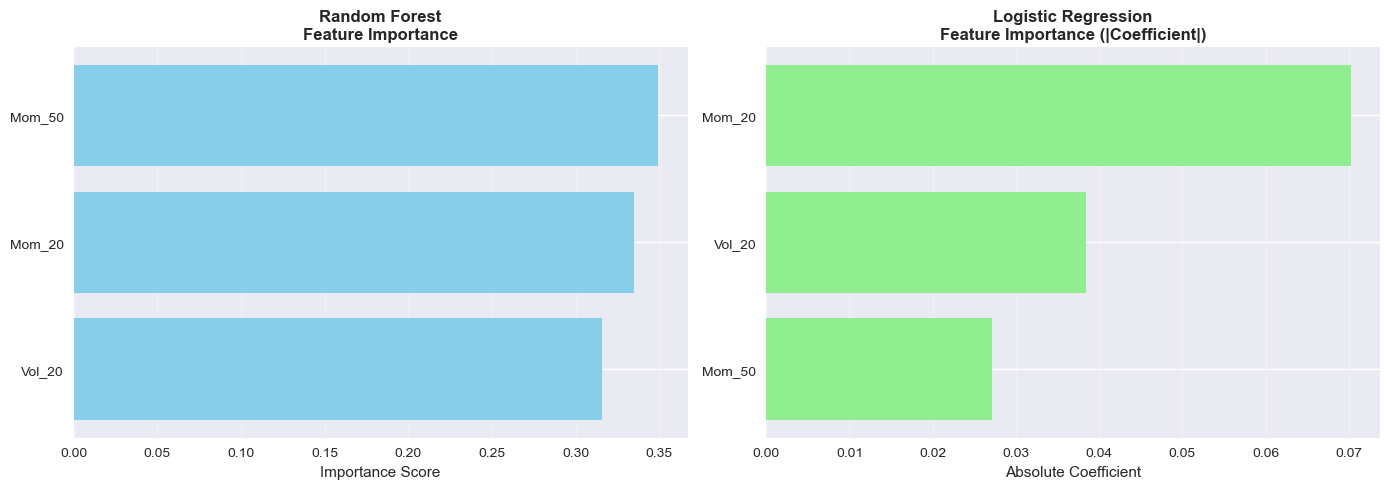


📊 Feature Importance Summary:

Random Forest:
Feature  Importance
 Mom_50    0.349341
 Mom_20    0.334772
 Vol_20    0.315886

Logistic Regression (with signs):
  Vol_20: -0.0385
  Mom_20: +0.0702
  Mom_50: -0.0271


In [10]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(rf_importance['Feature'], rf_importance['Importance'], color='skyblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Random Forest\nFeature Importance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Logistic Regression coefficients (absolute values)
lr_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=True)

axes[1].barh(lr_importance['Feature'], lr_importance['Coefficient'], color='lightgreen')
axes[1].set_xlabel('Absolute Coefficient', fontsize=11)
axes[1].set_title('Logistic Regression\nFeature Importance (|Coefficient|)', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Summary:")
print("\nRandom Forest:")
print(rf_importance.sort_values('Importance', ascending=False).to_string(index=False))
print("\nLogistic Regression (with signs):")
for feature, coef in zip(X_train.columns, lr_model.coef_[0]):
    print(f"  {feature}: {coef:+.4f}")

## 9. Summary & Next Steps

In [11]:
print("\n" + "="*70)
print("STEP 1: BASELINE COMPARISON SUMMARY")
print("="*70)

print("\n📊 CONFIGURATION:")
print(f"  Features: 3 (Vol_20, Mom_20, Mom_50)")
print(f"  Training: 2023-2024 ({len(X_train)} samples)")
print(f"  Testing: 2025 ({len(X_test)} samples)")

print("\n🏆 PERFORMANCE (Test Set):")
test_results = results_df[results_df['Dataset'] == 'Testing']
print(test_results.to_string(index=False))

# Determine winner
rf_test_acc = test_results[test_results['Model'] == 'Random Forest']['Accuracy'].values[0]
lr_test_acc = test_results[test_results['Model'] == 'Logistic Regression']['Accuracy'].values[0]

print("\n🎯 WINNER:")
if rf_test_acc > lr_test_acc:
    print(f"  ✅ Random Forest ({rf_test_acc:.2%} accuracy)")
    print(f"  Margin: +{(rf_test_acc - lr_test_acc)*100:.2f}%")
elif lr_test_acc > rf_test_acc:
    print(f"  ✅ Logistic Regression ({lr_test_acc:.2%} accuracy)")
    print(f"  Margin: +{(lr_test_acc - rf_test_acc)*100:.2f}%")
else:
    print(f"  🤝 TIE ({rf_test_acc:.2%} accuracy)")

print("\n💡 INSIGHTS:")
if rf_test_acc > lr_test_acc:
    print("  • Random Forest captures non-linear patterns better")
    print("  • Market regime has complex, non-linear relationships")
else:
    print("  • Linear model performs surprisingly well")
    print("  • Market regime may have strong linear components")
    print("  • Simpler model = better interpretability")

print("\n📈 NEXT STEPS:")
print("  Step 2: Add multi-timeframe features (Vol_5, Mom_5, Mom_10)")
print("  Step 3: Add statistical features (Skewness, Kurtosis)")
print("  Step 4: Add cross-asset features (Correlation, Dispersion)")
print("  Step 5: Final model selection & optimization")

print("\n" + "="*70)


STEP 1: BASELINE COMPARISON SUMMARY

📊 CONFIGURATION:
  Features: 3 (Vol_20, Mom_20, Mom_50)
  Training: 2023-2024 (562 samples)
  Testing: 2025 (365 samples)

🏆 PERFORMANCE (Test Set):
              Model Dataset  Accuracy  Precision   Recall  F1-Score
      Random Forest Testing  0.520548   0.539326 0.734694  0.622030
Logistic Regression Testing  0.536986   0.536986 1.000000  0.698752

🎯 WINNER:
  ✅ Logistic Regression (53.70% accuracy)
  Margin: +1.64%

💡 INSIGHTS:
  • Linear model performs surprisingly well
  • Market regime may have strong linear components
  • Simpler model = better interpretability

📈 NEXT STEPS:
  Step 2: Add multi-timeframe features (Vol_5, Mom_5, Mom_10)
  Step 3: Add statistical features (Skewness, Kurtosis)
  Step 4: Add cross-asset features (Correlation, Dispersion)
  Step 5: Final model selection & optimization

